In [5]:
using DataFrames, Turing

In [ ]:
@model function fit_lensed(x, y)

    b ~ truncated(Normal(1., 1), 0, 5)
    s  ~ truncated(Normal(0., 1), 0, b)

    y ~ Normal(x-b,s)
end

fit_lensed (generic function with 2 methods)

In [76]:
x_obs = 0.03 .*Vector(1:100) .* ( 1 .+ 0.1 .* ( - 0.5 .+ rand(100)));
y_obs = (2 .+ 1.5 .* x_obs) .* ( 1 .+ 0.1 .* ( - 0.5 .+ rand(100)));

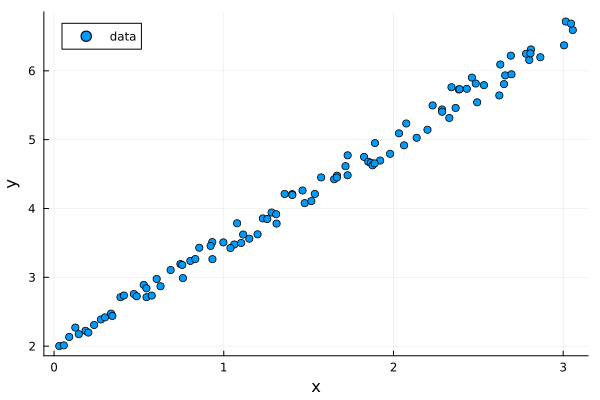

In [105]:
scatter(x_obs, y_obs, label="data", xlabel="x", ylabel="y")

In [156]:
@model function linear_regression(x, y)
    α ~ Normal(0, 10)
    β ~ Normal(0, 10)
    #σ ~ Exponential(1)
    
    
    for i in 1:length(y)
        y[i] ~ Normal(α + β * x[i], 1)
    end
    #y ~ Normal(sum(α .+ β .* x), 1)
end

linear_regression (generic function with 2 methods)

In [157]:
chain = sample(linear_regression(x_obs, y_obs), NUTS(), 1_500)

Sampling   0%|                                          |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.05
└ @ Turing.Inference /Users/cyan/.julia/packages/Turing/UCuzt/src/mcmc/hmc.jl:192
Sampling   0%|▎                                         |  ETA: 0:02:02
Sampling   1%|▍                                         |  ETA: 0:01:01
Sampling   1%|▋                                         |  ETA: 0:00:40
Sampling   2%|▉                                         |  ETA: 0:00:30
Sampling   2%|█                                         |  ETA: 0:00:24
Sampling   3%|█▎                                        |  ETA: 0:00:20
Sampling   3%|█▍                                        |  ETA: 0:00:17
Sampling   4%|█▋                                        |  ETA: 0:00:15
Sampling   4%|█▉                                        |  ETA: 0:00:13
Sampling   5%|██                                        |  ETA: 0:00:12
Sampling   5%|██▎                                       |  ETA: 0:00:11
Sampling   6%

Chains MCMC chain (1500×14×1 Array{Float64, 3}):

Iterations        = 751:1:2250
Number of chains  = 1
Samples per chain = 1500
Wall duration     = 0.94 seconds
Compute duration  = 0.94 seconds
parameters        = α, β
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

           α    1.9801    0.1987    0.0091   473.7086   619.5491    1.0027     ⋯
           β    1.5024    0.1149    0.0053   475.1408   541.2859    1.0024     ⋯
                                                                1 column omitted

Quantiles
  parameters      2.5%     25.0%     50.0%     75.0%     97.5% 
      Symbol   Float64   Float64   Float64   Float64   Float64 

           

In [158]:
chain[:β];

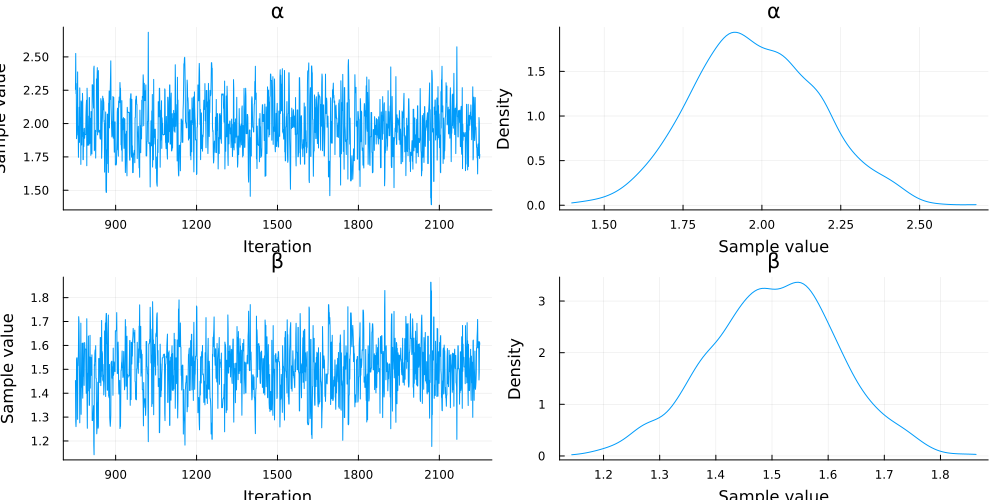

In [159]:
plot(chain)

In [145]:
x_pred = collect(0:0.1:4)
μ_pred = chain[:α] .+ chain[:β] .* x_pred'
#y_pred = rand.(Normal.(μ_pred, chain[:σ]));

1500×41 Matrix{Float64}:
 1.7987   1.96345  2.12819  2.29293  …  7.8942   8.05895  8.22369  8.38843
 1.8654   2.02841  2.19142  2.35443     7.89668  8.05968  8.22269  8.3857
 1.94942  2.10565  2.26188  2.41811     7.72991  7.88614  8.04237  8.1986
 1.96653  2.13063  2.29472  2.45882     8.0382   8.2023   8.3664   8.5305
 2.08733  2.22498  2.36262  2.50027     7.18034  7.31799  7.45564  7.59329
 2.0418   2.17753  2.31326  2.44899  …  7.06374  7.19946  7.33519  7.47092
 2.04157  2.17781  2.31405  2.45029     7.08248  7.21872  7.35497  7.49121
 1.70687  1.86786  2.02885  2.18984     7.66355  7.82454  7.98553  8.14652
 1.84275  2.00558  2.16841  2.33125     7.86755  8.03039  8.19322  8.35605
 1.77914  1.94825  2.11736  2.28647     8.03627  8.20538  8.37449  8.5436
 ⋮                                   ⋱                             ⋮
 2.00672  2.15656  2.30639  2.45622     7.5505   7.70033  7.85016  7.99999
 2.11845  2.26073  2.40301  2.54528     7.3827   7.52498  7.66726  7.80954
 2.05312  

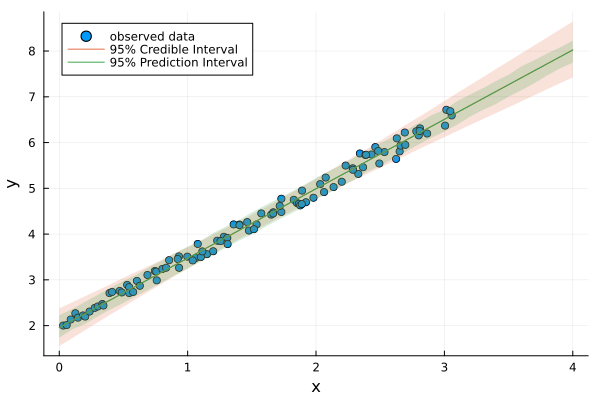

In [146]:
# 95% 信用区間
lower_μ = [quantile(μ_pred[:,i], 0.025) for i in 1:length(x_pred)]
upper_μ = [quantile(μ_pred[:,i], 0.975) for i in 1:length(x_pred)]

# 95% 予測区間
lower_y = [quantile(y_pred[:,i], 0.025) for i in 1:length(x_pred)]
upper_y = [quantile(y_pred[:,i], 0.975) for i in 1:length(x_pred)]

# 予測分布の可視化
scatter(x_obs, y_obs, label="observed data", xlabel="x", ylabel="y")
μ_pred_mean = mean(μ_pred, dims=1)'
plot!(x_pred, μ_pred_mean, ribbon=(μ_pred_mean .- lower_μ, upper_μ .- μ_pred_mean), fillalpha=0.2, label="95% Credible Interval")
plot!(x_pred, μ_pred_mean, ribbon=(μ_pred_mean .- lower_y, upper_y .- μ_pred_mean), fillalpha=0.2, label="95% Prediction Interval")

In [147]:
loglikelihood(linear_regression(2., 1.5), chain)'

1×1500 adjoint(::Matrix{Float64}) with eltype Float64:
 -7.3758  -7.49125  -7.30572  …  -6.6244  -6.6244  -6.7797  -7.43336

In [148]:
a = rand(100,100);
b = rand(10000);

In [120]:
@time sum(a)

  0.000009 seconds (1 allocation: 16 bytes)


4961.756221103475

In [121]:
@time sum(b)

  0.000006 seconds (1 allocation: 16 bytes)


4973.404711708329